# Name: Anthony Curcio-Petraccoro
# Assignment: Homework 4
# Date: 03/31/2026
# Course: CS 559 (Spring 2026)
# Course Instructor: Professor Landaeta
# I pledge my honor that I have abided by the Stevens Honor System.

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR

# Question 1: Non-parametric model selection [100 pts]

In [2]:
train_df = pd.read_csv("processed_training_data.csv")
test_df  = pd.read_csv("processed_testing_data.csv")

# homework 3 already produced the processed train/test datasets from before
print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nColumns:")
print(train_df.columns.tolist())

Training shape: (257, 11)
Test shape: (65, 11)

Columns:
['CRuns', 'CRBI', 'CHits', 'CHmRun', 'CAtBat', 'RBI', 'Walks', 'CWalks', 'Hits', 'Runs', 'Salary']


In [3]:
# all available features (the target is the salary)
all_features = ["CRuns", "CRBI", "CHits", "CHmRun", "CAtBat", "RBI", "Walks", "CWalks", "Hits", "Runs"]

# the three nested subsets of for curse of dimensionality analysis
subset_3 = ["CRuns", "CRBI", "CHits"]
subset_6 = ["CRuns", "CRBI", "CHits", "CHmRun", "CAtBat", "RBI"]
subset_10 = all_features  

feature_subsets = [subset_3, subset_6, subset_10]
subset_labels = [3, 6, 10]
target = "Salary"

def get_scaled_data(subset):
    X_train = train_df[subset].values
    y_train = train_df[target].values
    X_test  = test_df[subset].values
    y_test = test_df[target].values
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    return X_train_s, y_train, X_test_s, y_test

print("Nested feature subsets defined:")
for lbl, sub in zip(subset_labels, feature_subsets):
    print(f"{lbl} features: {sub}")

Nested feature subsets defined:
3 features: ['CRuns', 'CRBI', 'CHits']
6 features: ['CRuns', 'CRBI', 'CHits', 'CHmRun', 'CAtBat', 'RBI']
10 features: ['CRuns', 'CRBI', 'CHits', 'CHmRun', 'CAtBat', 'RBI', 'Walks', 'CWalks', 'Hits', 'Runs']


# Section A: Neural Network (MLP Regressor)

In [4]:
# neral network - hyperparameter tuning and curse of dimensionality
nn_param_grid = {
    "hidden_layer_sizes": [(10,), (50,), (100,), (50, 25), (100, 50)],
    "activation": ["relu"],
    "max_iter": [2000],
    "learning_rate_init": [0.001]
}

nn_cod_times = []
nn_cod_train_r2 = []
nn_cod_test_r2 = []
nn_best_params_list = []

for subset in feature_subsets:
    X_tr, y_tr, X_te, y_te = get_scaled_data(subset)
    gs = GridSearchCV(MLPRegressor(random_state=42), nn_param_grid, cv=5, scoring="r2", n_jobs=-1)      
    t0 = time.time()
    gs.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    best_model = gs.best_estimator_
    train_r2 = r2_score(y_tr, best_model.predict(X_tr))
    test_r2 = r2_score(y_te, best_model.predict(X_te))
    nn_cod_times.append(elapsed)
    nn_cod_train_r2.append(train_r2)
    nn_cod_test_r2.append(test_r2)
    nn_best_params_list.append(gs.best_params_)

    print("Number of features:", len(subset))
    print("Best parameters:", gs.best_params_)
    print("Train R2:", round(train_r2, 4))
    print("Test R2:", round(test_r2, 4))
    print("Time:", round(elapsed, 2), "seconds")
    print("\n")

Number of features: 3
Best parameters: {'activation': 'relu', 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.001, 'max_iter': 2000}
Train R2: 0.2628
Test R2: 0.3495
Time: 8.69 seconds


Number of features: 6
Best parameters: {'activation': 'relu', 'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.001, 'max_iter': 2000}
Train R2: 0.3687
Test R2: 0.3783
Time: 2.95 seconds


Number of features: 10
Best parameters: {'activation': 'relu', 'hidden_layer_sizes': (50, 25), 'learning_rate_init': 0.001, 'max_iter': 2000}
Train R2: 0.5864
Test R2: 0.5417
Time: 3.88 seconds




In [5]:
# neural network - Bias-Variance Tradeoff (# weights)
def count_weights(arch, n_input, n_output=1):
    sizes = [n_input] + list(arch) + [n_output]
    total = 0
    for i in range(len(sizes) - 1):
        # weights and biases here
        total += sizes[i] * sizes[i + 1] + sizes[i + 1]
    return total

nn_architectures = [(5,), (10,), (20,), (50,), (100,), (20, 10), (50, 25), (100, 50), (100, 50, 25)]

X_tr_full, y_tr_full, X_te_full, y_te_full = get_scaled_data(subset_10)
n_input = len(subset_10)

nn_bv_weights = []
nn_bv_train_r2 = []
nn_bv_test_r2 = []

for arch in nn_architectures:
    model = MLPRegressor(hidden_layer_sizes=arch, activation="relu", max_iter=4000, random_state=42, learning_rate_init=0.001)
    model.fit(X_tr_full, y_tr_full)
    tr2 = r2_score(y_tr_full, model.predict(X_tr_full))
    te2 = r2_score(y_te_full, model.predict(X_te_full))
    nw = count_weights(arch, n_input)
    nn_bv_weights.append(nw)
    nn_bv_train_r2.append(tr2)
    nn_bv_test_r2.append(te2)
    print("Architecture:", arch)
    print("Number of weights:", nw)
    print("Train R2:", round(tr2, 4))
    print("Test R2:", round(te2, 4))
    print("\n")

Architecture: (5,)
Number of weights: 61
Train R2: 0.1213
Test R2: 0.2656


Architecture: (10,)
Number of weights: 121
Train R2: 0.432
Test R2: 0.4189


Architecture: (20,)
Number of weights: 241
Train R2: 0.4735
Test R2: 0.4595


Architecture: (50,)
Number of weights: 601
Train R2: 0.582
Test R2: 0.5286


Architecture: (100,)
Number of weights: 1201
Train R2: 0.613
Test R2: 0.5243


Architecture: (20, 10)
Number of weights: 441
Train R2: 0.6268
Test R2: 0.4846


Architecture: (50, 25)
Number of weights: 1851
Train R2: 0.5864
Test R2: 0.5417


Architecture: (100, 50)
Number of weights: 6201
Train R2: 0.5009
Test R2: 0.4817


Architecture: (100, 50, 25)
Number of weights: 7451
Train R2: 0.6651
Test R2: 0.4545




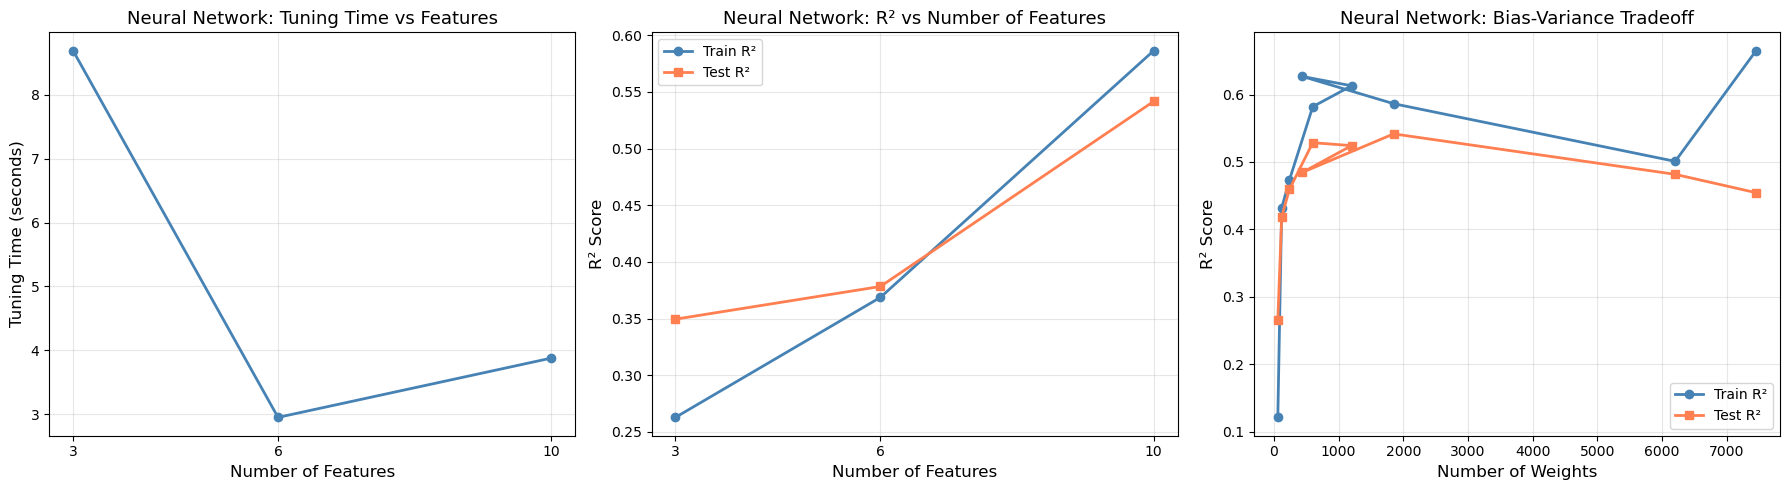

In [6]:
# neural network visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# plot #1 - tuning time vs number of features (curse of dimensionality)
axes[0].plot(subset_labels, nn_cod_times, marker="o", color="steelblue", linewidth=2)
axes[0].set_xlabel("Number of Features", fontsize=12)
axes[0].set_ylabel("Tuning Time (seconds)", fontsize=12)
axes[0].set_title("Neural Network: Tuning Time vs Features", fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(subset_labels)

# plot #2- train/test R^2 vs number of features (curse of dimensionality)
axes[1].plot(subset_labels, nn_cod_train_r2, marker="o", label="Train R²", color="steelblue", linewidth=2)
axes[1].plot(subset_labels, nn_cod_test_r2,  marker="s", label="Test R²",  color="coral",    linewidth=2)
axes[1].set_xlabel("Number of Features", fontsize=12)
axes[1].set_ylabel("R² Score", fontsize=12)
axes[1].set_title("Neural Network: R² vs Number of Features", fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(subset_labels)

# plot #3 - bias-variance tradeoff (number of weights)
axes[2].plot(nn_bv_weights, nn_bv_train_r2, marker="o", label="Train R²", color="steelblue", linewidth=2)
axes[2].plot(nn_bv_weights, nn_bv_test_r2,  marker="s", label="Test R²",  color="coral",    linewidth=2)
axes[2].set_xlabel("Number of Weights", fontsize=12)
axes[2].set_ylabel("R² Score", fontsize=12)
axes[2].set_title("Neural Network: Bias-Variance Tradeoff", fontsize=13)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("nn_plots.png", dpi=150, bbox_inches="tight")
plt.show()

# Section A: k-Nearest Neighbors (kNN)

In [7]:
# kNN - hyperparrameter tuning and curse of dimensionality
knn_param_grid = {"n_neighbors": [3, 5, 7, 10, 15, 20, 25], "weights": ["uniform", "distance"], "metric": ["euclidean", "manhattan"]}

knn_cod_times = []
knn_cod_train_r2 = []
knn_cod_test_r2 = []
knn_best_params_list = []

for subset in feature_subsets:
    X_tr, y_tr, X_te, y_te = get_scaled_data(subset)
    gs = GridSearchCV(KNeighborsRegressor(), knn_param_grid, cv=5, scoring="r2", n_jobs=-1)
    t0 = time.time()
    gs.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    best_model = gs.best_estimator_
    train_r2   = r2_score(y_tr, best_model.predict(X_tr))
    test_r2    = r2_score(y_te, best_model.predict(X_te))
    knn_cod_times.append(elapsed)
    knn_cod_train_r2.append(train_r2)
    knn_cod_test_r2.append(test_r2)
    knn_best_params_list.append(gs.best_params_)
    print("Number of features:", len(subset))
    print("Best parameters:", gs.best_params_)
    print("Train R2:", round(train_r2, 4))
    print("Test R2:", round(test_r2, 4))
    print("Time:", round(elapsed, 2), "seconds")
    print("\n")

Number of features: 3
Best parameters: {'metric': 'manhattan', 'n_neighbors': 20, 'weights': 'uniform'}
Train R2: 0.3587
Test R2: 0.4376
Time: 0.32 seconds


Number of features: 6
Best parameters: {'metric': 'euclidean', 'n_neighbors': 20, 'weights': 'distance'}
Train R2: 1.0
Test R2: 0.4919
Time: 0.08 seconds


Number of features: 10
Best parameters: {'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'distance'}
Train R2: 1.0
Test R2: 0.4858
Time: 0.09 seconds




In [8]:
# kNN - bias-variance tradeoff (k vs R^2)
# Small k is lower bias, higher variance
# Large k is higher bias, lower variance

X_tr_full, y_tr_full, X_te_full, y_te_full = get_scaled_data(subset_10)
n_input = len(subset_10)  

k_values = [1, 2, 3, 5, 7, 10, 15, 20, 25, 30, 40, 50]

knn_bv_k = []
knn_bv_train_r2 = []
knn_bv_test_r2 = []

best_knn = knn_best_params_list[-1]

for k in k_values:
    model = KNeighborsRegressor(
        n_neighbors=k,
        weights=best_knn["weights"],
        metric=best_knn["metric"]
    )    
    model.fit(X_tr_full, y_tr_full)
    tr2 = r2_score(y_tr_full, model.predict(X_tr_full))
    te2 = r2_score(y_te_full, model.predict(X_te_full))
    knn_bv_k.append(k)
    knn_bv_train_r2.append(tr2)
    knn_bv_test_r2.append(te2)
    print("k:", k)
    print("Train R2:", round(tr2, 4))
    print("Test R2:", round(te2, 4))
    print("\n")

k: 1
Train R2: 1.0
Test R2: -0.1472


k: 2
Train R2: 1.0
Test R2: 0.1785


k: 3
Train R2: 1.0
Test R2: 0.2237


k: 5
Train R2: 1.0
Test R2: 0.3516


k: 7
Train R2: 1.0
Test R2: 0.4117


k: 10
Train R2: 1.0
Test R2: 0.4858


k: 15
Train R2: 1.0
Test R2: 0.5059


k: 20
Train R2: 1.0
Test R2: 0.5113


k: 25
Train R2: 1.0
Test R2: 0.5289


k: 30
Train R2: 1.0
Test R2: 0.5311


k: 40
Train R2: 1.0
Test R2: 0.5227


k: 50
Train R2: 1.0
Test R2: 0.5127




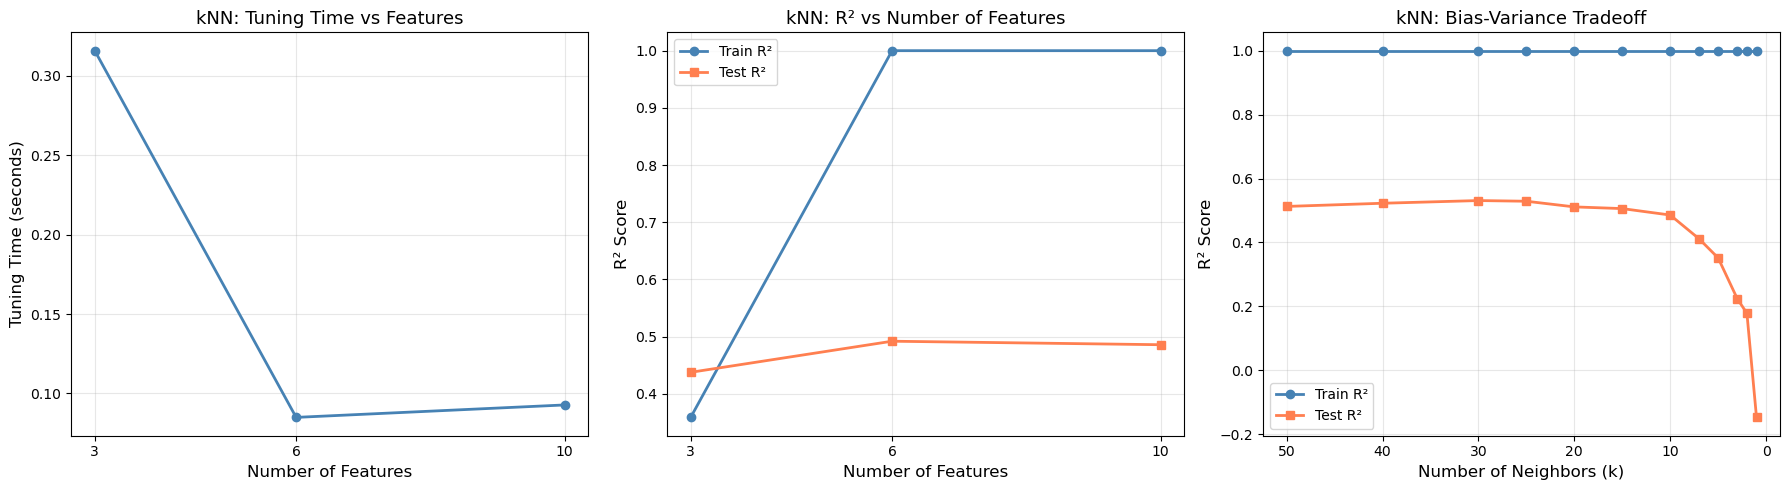

In [9]:
# kNN vizuals
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(subset_labels, knn_cod_times, marker="o", color="steelblue", linewidth=2)
axes[0].set_xlabel("Number of Features", fontsize=12)
axes[0].set_ylabel("Tuning Time (seconds)", fontsize=12)
axes[0].set_title("kNN: Tuning Time vs Features", fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(subset_labels)

axes[1].plot(subset_labels, knn_cod_train_r2, marker="o", label="Train R²", color="steelblue", linewidth=2)
axes[1].plot(subset_labels, knn_cod_test_r2,  marker="s", label="Test R²",  color="coral",    linewidth=2)
axes[1].set_xlabel("Number of Features", fontsize=12)
axes[1].set_ylabel("R² Score", fontsize=12)
axes[1].set_title("kNN: R² vs Number of Features", fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(subset_labels)

axes[2].plot(knn_bv_k, knn_bv_train_r2, marker="o", label="Train R²", color="steelblue", linewidth=2)
axes[2].plot(knn_bv_k, knn_bv_test_r2,  marker="s", label="Test R²",  color="coral",    linewidth=2)
axes[2].set_xlabel("Number of Neighbors (k)", fontsize=12)
axes[2].set_ylabel("R² Score", fontsize=12)
axes[2].set_title("kNN: Bias-Variance Tradeoff", fontsize=13)
# k is on the right
axes[2].invert_xaxis()
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("knn_plots.png", dpi=150, bbox_inches="tight")
plt.show()

# Section A: Kernel Ridge Regression

In [10]:
# kernel Ridge - hyperparameter tuning and curse of dimensionality
kr_param_grid = {"alpha":  [0.01, 0.1, 1.0, 10.0, 100.0], "kernel": ["rbf"], "gamma":  [0.001, 0.01, 0.1, 1.0]}

kr_cod_times = []
kr_cod_train_r2 = []
kr_cod_test_r2 = []
kr_best_params_list = []

for subset in feature_subsets:
    X_tr, y_tr, X_te, y_te = get_scaled_data(subset)
    gs = GridSearchCV(KernelRidge(), kr_param_grid, cv=5, scoring="r2", n_jobs=-1)
    t0 = time.time()
    gs.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    best_model = gs.best_estimator_
    train_r2   = r2_score(y_tr, best_model.predict(X_tr))
    test_r2    = r2_score(y_te, best_model.predict(X_te))
    kr_cod_times.append(elapsed)
    kr_cod_train_r2.append(train_r2)
    kr_cod_test_r2.append(test_r2)
    kr_best_params_list.append(gs.best_params_)
    print("Number of features:", len(subset))
    print("Best parameters:", gs.best_params_)
    print("Train R2:", round(train_r2, 4))
    print("Test R2:", round(test_r2, 4))
    print("Time:", round(elapsed, 2), "seconds")
    print("\n")

Number of features: 3
Best parameters: {'alpha': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}
Train R2: 0.3225
Test R2: 0.3739
Time: 0.08 seconds


Number of features: 6
Best parameters: {'alpha': 0.01, 'gamma': 0.01, 'kernel': 'rbf'}
Train R2: 0.5598
Test R2: 0.607
Time: 0.08 seconds


Number of features: 10
Best parameters: {'alpha': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
Train R2: 0.5895
Test R2: 0.6105
Time: 0.08 seconds




In [11]:
# kernel ridge - bias-variance tradeoff (Alpha vs R^2)
# low alpha is low regularization, which is high complexity. high alpha is strong regularization
alpha_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]
best_gamma_kr = kr_best_params_list[-1].get("gamma", 0.1)

kr_bv_alpha = []
kr_bv_train_r2 = []
kr_bv_test_r2 = []

for alpha in alpha_values:
    model = KernelRidge(kernel="rbf", alpha=alpha, gamma=best_gamma_kr)
    model.fit(X_tr_full, y_tr_full)
    tr2 = r2_score(y_tr_full, model.predict(X_tr_full))
    te2 = r2_score(y_te_full, model.predict(X_te_full))
    kr_bv_alpha.append(alpha)
    kr_bv_train_r2.append(tr2)
    kr_bv_test_r2.append(te2)
    print("Alpha:", round(alpha, 3))
    print("Train R2:", round(tr2, 4))
    print("Test R2:", round(te2, 4))
    print("\n")

Alpha: 0.001
Train R2: 0.7574
Test R2: 0.0792


Alpha: 0.005
Train R2: 0.6953
Test R2: 0.3537


Alpha: 0.01
Train R2: 0.6706
Test R2: 0.4495


Alpha: 0.05
Train R2: 0.6146
Test R2: 0.586


Alpha: 0.1
Train R2: 0.5895
Test R2: 0.6105


Alpha: 0.5
Train R2: 0.5202
Test R2: 0.5976


Alpha: 1.0
Train R2: 0.4813
Test R2: 0.5637


Alpha: 5.0
Train R2: 0.3739
Test R2: 0.4525


Alpha: 10.0
Train R2: 0.3161
Test R2: 0.3935




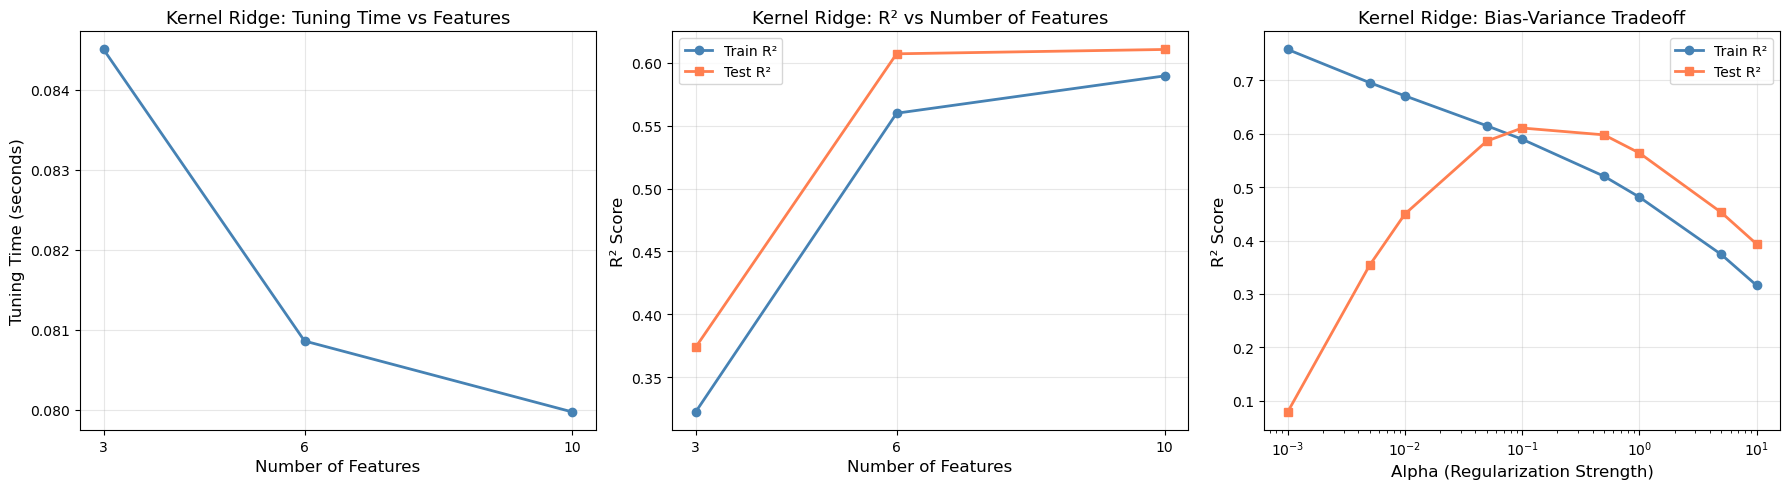

In [12]:
# kernel ridge visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(subset_labels, kr_cod_times, marker="o", color="steelblue", linewidth=2)
axes[0].set_xlabel("Number of Features", fontsize=12)
axes[0].set_ylabel("Tuning Time (seconds)", fontsize=12)
axes[0].set_title("Kernel Ridge: Tuning Time vs Features", fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(subset_labels)

axes[1].plot(subset_labels, kr_cod_train_r2, marker="o", label="Train R²", color="steelblue", linewidth=2)
axes[1].plot(subset_labels, kr_cod_test_r2,  marker="s", label="Test R²",  color="coral",    linewidth=2)
axes[1].set_xlabel("Number of Features", fontsize=12)
axes[1].set_ylabel("R² Score", fontsize=12)
axes[1].set_title("Kernel Ridge: R² vs Number of Features", fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(subset_labels)

axes[2].plot(kr_bv_alpha, kr_bv_train_r2, marker="o", label="Train R²", color="steelblue", linewidth=2)
axes[2].plot(kr_bv_alpha, kr_bv_test_r2,  marker="s", label="Test R²",  color="coral",    linewidth=2)
axes[2].set_xlabel("Alpha (Regularization Strength)", fontsize=12)
axes[2].set_ylabel("R² Score", fontsize=12)
axes[2].set_title("Kernel Ridge: Bias-Variance Tradeoff", fontsize=13)
axes[2].set_xscale("log")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("kr_plots.png", dpi=150, bbox_inches="tight")
plt.show()

# Section A: Support Vector Machine (SVR)

In [13]:
# svm - hyperparameter tuning and curse of dimensionality
svm_param_grid = {"C": [0.1, 1.0, 10.0, 100.0, 500.0], "kernel": ["rbf"], "gamma": ["scale", 0.01, 0.1], "epsilon": [0.01, 0.05, 0.1, 0.5]}

svm_cod_times = []
svm_cod_train_r2 = []
svm_cod_test_r2 = []
svm_best_params_list = []

for subset in feature_subsets:
    X_tr, y_tr, X_te, y_te = get_scaled_data(subset)
    gs = GridSearchCV(SVR(), svm_param_grid, cv=5, scoring="r2", n_jobs=-1)
    t0 = time.time()
    gs.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    best_model = gs.best_estimator_
    train_r2   = r2_score(y_tr, best_model.predict(X_tr))
    test_r2    = r2_score(y_te, best_model.predict(X_te))
    svm_cod_times.append(elapsed)
    svm_cod_train_r2.append(train_r2)
    svm_cod_test_r2.append(test_r2)
    svm_best_params_list.append(gs.best_params_)
    print("Number of features:", len(subset))
    print("Best parameters:", gs.best_params_)
    print("Train R2:", round(train_r2, 4))
    print("Test R2:", round(test_r2, 4))
    print("Time:", round(elapsed, 2), "seconds")
    print("\n")

Number of features: 3
Best parameters: {'C': 500.0, 'epsilon': 0.5, 'gamma': 0.1, 'kernel': 'rbf'}
Train R2: 0.2813
Test R2: 0.3606
Time: 0.21 seconds


Number of features: 6
Best parameters: {'C': 500.0, 'epsilon': 0.01, 'gamma': 0.1, 'kernel': 'rbf'}
Train R2: 0.4666
Test R2: 0.5481
Time: 0.2 seconds


Number of features: 10
Best parameters: {'C': 500.0, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'rbf'}
Train R2: 0.5781
Test R2: 0.4594
Time: 0.2 seconds




In [14]:
# svm - bias-variance tradeoff (C vs R^2)
# C is low regularization for high model complexity. c is for smooth boundary
C_values = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0]

best_eps = svm_best_params_list[-1].get("epsilon", 0.1)
best_gam = svm_best_params_list[-1].get("gamma", "scale")

svm_bv_C = []
svm_bv_train_r2 = []
svm_bv_test_r2 = []

for c in C_values:
    model = SVR(kernel="rbf", C=c, gamma=best_gam, epsilon=best_eps)
    model.fit(X_tr_full, y_tr_full)
    tr2 = r2_score(y_tr_full, model.predict(X_tr_full))
    te2 = r2_score(y_te_full, model.predict(X_te_full))
    svm_bv_C.append(c)
    svm_bv_train_r2.append(tr2)
    svm_bv_test_r2.append(te2)
    print("C:", round(c, 3))
    print("Train R2:", round(tr2, 4))
    print("Test R2:", round(te2, 4))
    print("\n")

C: 0.01
Train R2: -0.0571
Test R2: -0.0077


C: 0.05
Train R2: -0.0549
Test R2: -0.0055


C: 0.1
Train R2: -0.0523
Test R2: -0.0028


C: 0.5
Train R2: -0.0312
Test R2: 0.0186


C: 1.0
Train R2: -0.0074
Test R2: 0.0429


C: 5.0
Train R2: 0.1118
Test R2: 0.1754


C: 10.0
Train R2: 0.202
Test R2: 0.2691


C: 50.0
Train R2: 0.4289
Test R2: 0.4641


C: 100.0
Train R2: 0.4887
Test R2: 0.4876


C: 500.0
Train R2: 0.5781
Test R2: 0.4594


C: 1000.0
Train R2: 0.646
Test R2: 0.4046




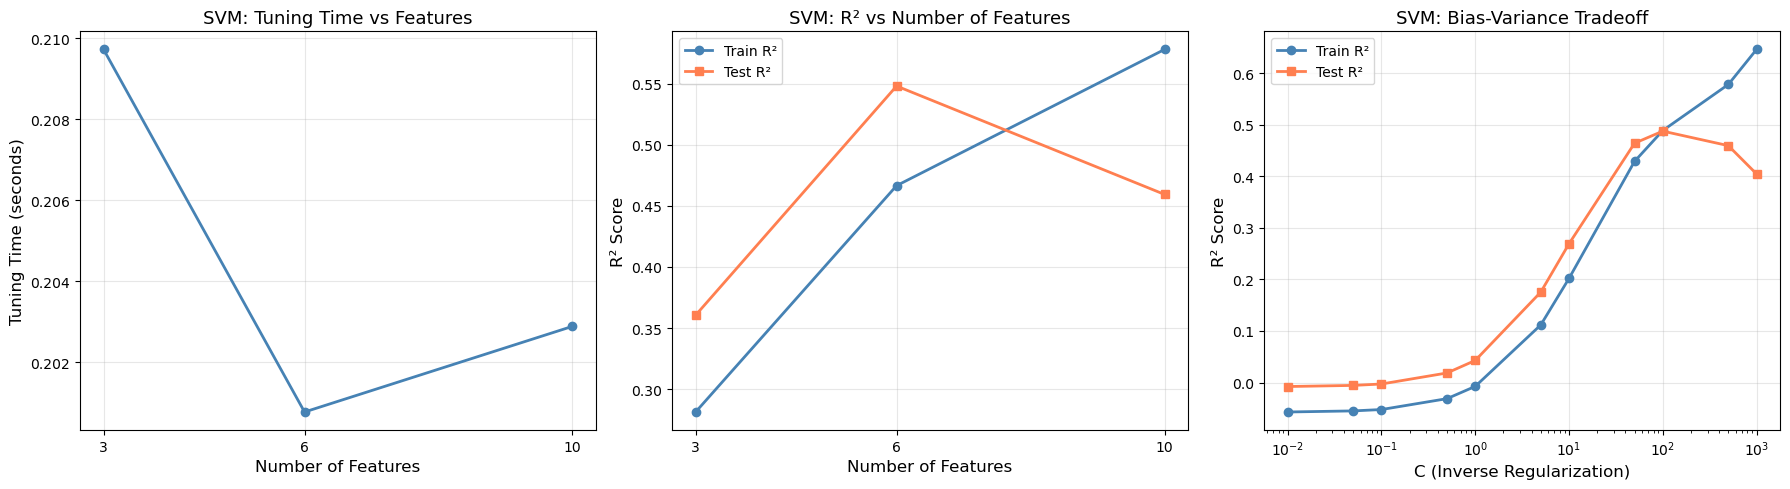

In [15]:
# svm visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(subset_labels, svm_cod_times, marker="o", color="steelblue", linewidth=2)
axes[0].set_xlabel("Number of Features", fontsize=12)
axes[0].set_ylabel("Tuning Time (seconds)", fontsize=12)
axes[0].set_title("SVM: Tuning Time vs Features", fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(subset_labels)

axes[1].plot(subset_labels, svm_cod_train_r2, marker="o", label="Train R²", color="steelblue", linewidth=2)
axes[1].plot(subset_labels, svm_cod_test_r2,  marker="s", label="Test R²",  color="coral",    linewidth=2)
axes[1].set_xlabel("Number of Features", fontsize=12)
axes[1].set_ylabel("R² Score", fontsize=12)
axes[1].set_title("SVM: R² vs Number of Features", fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(subset_labels)

axes[2].plot(svm_bv_C, svm_bv_train_r2, marker="o", label="Train R²", color="steelblue", linewidth=2)
axes[2].plot(svm_bv_C, svm_bv_test_r2,  marker="s", label="Test R²",  color="coral",    linewidth=2)
axes[2].set_xlabel("C (Inverse Regularization)", fontsize=12)
axes[2].set_ylabel("R² Score", fontsize=12)
axes[2].set_title("SVM: Bias-Variance Tradeoff", fontsize=13)
axes[2].set_xscale("log")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("svm_plots.png", dpi=150, bbox_inches="tight")
plt.show()

# Section B & C: Model Comparison Summary

Model                  Train R2    Test R2
---
Neural Network           0.5864     0.5417
kNN                      1.0000     0.4858
Kernel Ridge             0.5895     0.6105
SVM                      0.5781     0.4594
---


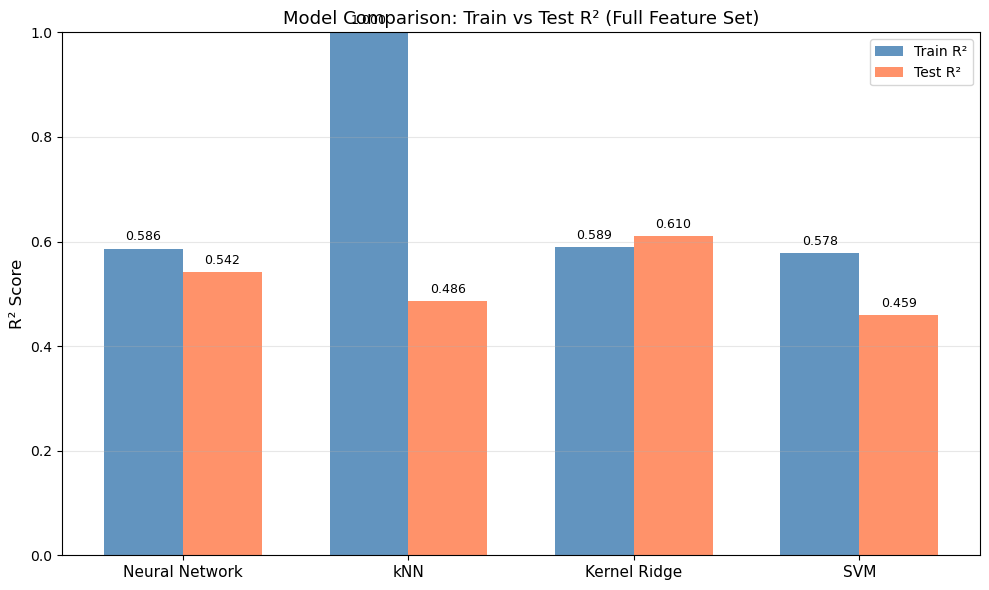

In [16]:
# final model comparison
model_results = {"Neural Network": {"train": nn_cod_train_r2[-1], "test": nn_cod_test_r2[-1]}, "kNN": {"train": knn_cod_train_r2[-1], "test": knn_cod_test_r2[-1]}, "Kernel Ridge":   {"train": kr_cod_train_r2[-1],  "test": kr_cod_test_r2[-1]}, "SVM": {"train": svm_cod_train_r2[-1], "test": svm_cod_test_r2[-1]},}

print(f"{'Model':<20} {'Train R2':>10} {'Test R2':>10}")
print("---")
for name, scores in model_results.items():
    print(f"{name:<20} {scores['train']:>10.4f} {scores['test']:>10.4f}")
print("---")

models = list(model_results.keys())
train_scores = [model_results[m]["train"] for m in models]
test_scores  = [model_results[m]["test"]  for m in models]
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, train_scores, width, label="Train R²", color="steelblue", alpha=0.85)
bars2 = ax.bar(x + width/2, test_scores,  width, label="Test R²",  color="coral",    alpha=0.85)

ax.set_ylabel("R² Score", fontsize=12)
ax.set_title("Model Comparison: Train vs Test R² (Full Feature Set)", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 1.0)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Conclusion: Best Model Selection

Based on the test R² scores across all four models using the full feature set,
Kernel Ridge achieved the highest test R² of 0.610, with a train R² of 0.589,
making it the best model. The small gap between train and test scores indicates
it generalized well without significant overfitting.

The Nural Network was close (test R² = 0.542) but was more
reactive to hyperparameter choices. kNN achieved a perfect train R² of 1.0,
indicating severe overfitting and poor generalization (test R² = 0.486). (test R² = 0.486).
This behavior is expected when the number of neighbors is small. SVM achieved the lowest test
performance (0.459), suggesting the model may have been slightly underfitting the dataset compared
to the other approaches. Kernel Ridge was therefore selected as the best overall model.